# 🏠 Airbnb Data Analysis — GitHub Copilot Workshop

Welcome! In this workshop you'll explore real Airbnb listing data for **New York, London, Paris, Amsterdam, and Barcelona** — and learn how **GitHub Copilot** can help you do more advanced analytical work without needing deep programming skills.

---

## What you'll learn
| Module | Theme |
|---|---|
| **1 — Understand the data** | Load a dataset and explore its structure with Copilot's help |
| **2 — Clean & prepare** | Spot and fix data quality issues faster using Copilot |
| **3 — Explore & visualise** | Generate charts from plain-English descriptions |
| **4 — SQL with DuckDB** | Run SQL queries on the data — no database server needed |
| **5 — Reusable functions** | Turn one-off scripts into functions you can use again |
| **6 — Explain & document** | Use Copilot to translate analysis into plain language |

---

## How to use Copilot in VS Code

| Action | How |
|---|---|
| Open Copilot Chat | `Ctrl+Alt+I` (Windows) / `Cmd+Option+I` (Mac) |
| Explain selected code | Select code → right-click → **Copilot: Explain** |
| Inline suggestion | Start typing a comment or code — Copilot autocompletes |
| Fix an error | Paste the error message into Copilot Chat |

Throughout this notebook you'll see **🤖 Copilot Prompts** — copy these into Copilot Chat to see how it responds.

In [2]:
# Install required packages
import subprocess, sys

packages = [
    "pandas", "numpy", "matplotlib", "seaborn",
    "plotly", "scipy", "requests", "duckdb"
]
for pkg in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

print("All packages installed.")

All packages installed.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import duckdb
import warnings, io, requests

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110

print("Libraries ready.")

Libraries ready.


---
## Module 1 — Understanding Your Data 🔍

The first step in any analysis is understanding what you're working with: how many rows, what columns, what data types, and where the gaps are. Copilot can help you do this faster by explaining what each column means and suggesting what to look at first.

**Finance & analytics context:** This mirrors connecting to a new data source — you need to understand the structure before you trust the numbers.

---
### 🤖 Copilot Prompts — try these as you run the cells below

> 💬 *"We have an Airbnb listings dataset with columns: id, name, host_id, neighbourhood, room_type, price, minimum_nights, number_of_reviews, availability_365, city. Which columns would be most useful for understanding what drives listing prices?"*

> 💬 *"The price column is missing for most rows in our dataset. What are the likely reasons for this, and how would you investigate it?"*

> 💬 *"Explain what the `availability_365` column likely represents in the context of an Airbnb listing, and what a very low or very high value would mean for a property owner."*

💡 **Tip:** You can select any code cell, right-click, and choose **Copilot: Explain** to get an inline explanation — useful when you inherit code you didn't write.

In [4]:
# Load data from Inside Airbnb — sample 2,000 rows per city
# This keeps the total dataset small so the workshop runs quickly.

SAMPLE_PER_CITY = 2_000

CITIES = {
    "New York":   "https://data.insideairbnb.com/united-states/ny/new-york-city/2026-02-13/visualisations/listings.csv",
    "London":     "https://data.insideairbnb.com/united-kingdom/england/london/2025-09-14/visualisations/listings.csv",
    "Paris":      "https://data.insideairbnb.com/france/ile-de-france/paris/2025-09-12/visualisations/listings.csv",
    "Amsterdam":  "https://data.insideairbnb.com/the-netherlands/north-holland/amsterdam/2025-09-11/visualisations/listings.csv",
    "Barcelona":  "https://data.insideairbnb.com/spain/catalonia/barcelona/2025-12-14/visualisations/listings.csv",
}

HEADERS = {
    "User-Agent": (
        "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/123.0 Safari/537.36"
    ),
    "Referer": "https://insideairbnb.com/",
}

frames = []
for city, url in CITIES.items():
    print(f"  Downloading {city} ...", end=" ", flush=True)
    try:
        r = requests.get(url, timeout=60, headers=HEADERS)
        r.raise_for_status()
        df_tmp = pd.read_csv(io.BytesIO(r.content))
        df_tmp["city"] = city
        # Sample immediately — keeps the dataset workshop-sized
        df_tmp = df_tmp.sample(min(SAMPLE_PER_CITY, len(df_tmp)), random_state=42)
        frames.append(df_tmp)
        print(f"✅  {len(df_tmp):,} rows")
    except Exception as e:
        print(f"⚠️  Failed: {e}")

df = pd.concat(frames, ignore_index=True)
print(f"\n📊 Workshop dataset: {df.shape[0]:,} rows × {df.shape[1]} columns")


📊 Workshop dataset: 10,000 rows × 20 columns


In [5]:
# First look: shape, column names, sample rows
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nListings per city:")
print(df["city"].value_counts().to_string())

df.head(5)

Shape: (10000, 20)

Columns: ['id', 'name', 'host_id', 'host_profile_id', 'host_name', 'neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'last_review', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365', 'number_of_reviews_ltm', 'license', 'city']

Listings per city:
city
New York     2000
London       2000
Paris        2000
Amsterdam    2000
Barcelona    2000


,id,name,host_id,host_profile_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license,city
0,1246333806730901018,A Room with Attached Bathroom,652181553,"1,470,640,229,371,105,024.00",Taly,Queens,Fresh Meadows,40.73,-73.79,Private room,NaN,30.00,0,NaN,NaN,1,365,0,NaN,New York
1,702011787477127477,The Tuscany Powered by LuxUrban - The Penthouse,215565541,"1,469,130,192,481,159,424.00",LuxUrban,Manhattan,Murray Hill,40.75,-73.98,Private room,NaN,30.00,0,NaN,NaN,31,365,0,NaN,New York
2,590041263854398620,Lovely 3-Bedroom with High Ceilings in Brooklyn,91846623,"1,467,109,533,932,190,976.00",Jason,Brooklyn,Bushwick,40.69,-73.92,Entire home/apt,NaN,31.00,2,2025-10-20,0.11,2,151,1,NaN,New York
3,760025165140763703,Cheerful 1 bedroom private home with your own ...,487676932,"1,470,194,720,513,293,312.00",Michael,Bronx,Clason Point,40.81,-73.86,Private room,NaN,30.00,1,2022-12-30,0.03,1,362,0,NaN,New York
4,18194482,Bed-Stuy Beauty,9945748,"1,462,827,716,917,216,768.00",Shakira,Brooklyn,Bedford-Stuyvesant,40.69,-73.94,Entire home/apt,NaN,30.00,13,2017-10-02,0.12,1,0,0,NaN,New York


In [6]:
# Data quality: missing values and data types
missing = (df.isnull().sum() / len(df) * 100).rename("missing_%").round(1)
dtypes  = df.dtypes.rename("dtype")
overview = pd.concat([dtypes, missing], axis=1).sort_values("missing_%", ascending=False)
print(overview.to_string())

                                  dtype  missing_%
price                           float64      76.00
host_profile_id                 float64      60.30
neighbourhood_group              object      60.00
license                          object      49.60
reviews_per_month               float64      23.40
last_review                         str      23.40
host_name                           str       0.30
number_of_reviews                 int64       0.00
number_of_reviews_ltm             int64       0.00
availability_365                  int64       0.00
calculated_host_listings_count    int64       0.00
id                                int64       0.00
minimum_nights                  float64       0.00
name                                str       0.00
room_type                           str       0.00
longitude                       float64       0.00
latitude                        float64       0.00
neighbourhood                       str       0.00
host_id                        

In [7]:
# Numeric summary statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,"10,000.00","610,979,692,675,628,672.00","583,146,027,057,130,496.00","7,097.00","28,082,199.25","699,017,876,604,779,648.00","1,152,147,081,969,241,472.00","1,615,638,826,135,372,544.00"
host_id,"10,000.00","190,282,218.65","209,903,819.56","3,073.00","18,614,382.25","83,198,583.50","346,367,515.00","732,603,145.00"
host_profile_id,"3,974.00","1,467,433,433,085,847,808.00","10,584,027,287,263,424.00","1,462,506,337,038,686,976.00","1,462,824,165,157,723,136.00","1,465,665,760,725,006,848.00","1,469,591,111,070,156,288.00","1,612,499,758,083,167,744.00"
latitude,"10,000.00",46.97,4.97,40.53,41.38,48.86,51.54,52.42
longitude,"10,000.00",-12.93,30.55,-74.17,-0.19,2.17,2.37,5.03
price,"2,397.00",274.80,"1,357.91",11.00,111.00,180.00,270.00,"50,000.00"
minimum_nights,"9,998.00",20.05,56.26,1.00,2.00,3.00,30.00,600.00
number_of_reviews,"10,000.00",35.62,99.58,0.00,1.00,6.00,28.00,"4,040.00"
reviews_per_month,"7,658.00",1.03,2.03,0.01,0.15,0.42,1.25,99.79
calculated_host_listings_count,"10,000.00",36.67,131.22,1.00,1.00,1.00,9.00,"1,210.00"


---
## Module 2 — Cleaning & Preparing Data 🧹

Real-world data is always messy. Here we'll fix data types, handle missing values, and create new columns that make the analysis more useful. Copilot is particularly good at suggesting the *right* way to handle data quality issues.

**Finance & analytics context:** This is the data validation step — the equivalent of checking your source data before building a report or model.

---
### 🤖 Copilot Prompts

> 💬 *"The price column in my DataFrame is missing for most cities. Write Python code to show exactly how many rows have a valid price per city, and what percentage that is of each city's total."*

> 💬 *"Add a new column called `price_tier` that categorises listings as Budget, Mid-range, or Luxury using the 33rd and 66th price percentiles within each city. Return 'Unknown' if price is missing."*

> 💬 *"I have a `minimum_nights` column with some extreme values over 365. Write code to classify listings as Short-term, Weekly, or Long-term based on this column."*

> 💬 *"Write code to check for and remove duplicate listing IDs, then print how many duplicates were found."*

💡 **Tip:** When prompting Copilot, mention the column names and data types — the more context you give, the better the result.

In [ ]:
# Clean price column — strip currency symbols if stored as text
if df["price"].dtype == object:
    df["price"] = (
        df["price"]
        .str.replace(r"[$,£€]", "", regex=True)
        .str.strip()
        .replace("", np.nan)
        .astype(float)
    )

# Flag rows with usable price data
df["has_price"] = df["price"].notna() & (df["price"] > 0)

# Cap outliers at the 99th percentile per city for cleaner charts
p99 = df.groupby("city")["price"].transform(lambda x: x.quantile(0.99))
df["price_capped"] = df["price"].clip(upper=p99)

# Ensure numeric types
for col in ["number_of_reviews", "reviews_per_month",
            "calculated_host_listings_count", "availability_365", "minimum_nights"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Classify rental duration based on minimum_nights
def classify_rental(min_nights):
    if pd.isna(min_nights):    return "Unknown"
    if min_nights >= 30:       return "Long-term (30+ nights)"
    if min_nights >= 7:        return "Weekly+"
    return "Short-term"

df["rental_type"] = df["minimum_nights"].apply(classify_rental)

print("Price availability by city:")
price_avail = df.groupby("city")["has_price"].mean().mul(100).round(1)
for city, pct in price_avail.items():
    bar = "█" * int(pct / 5)
    print(f"  {city:<12} {bar:<20} {pct}%")

In [ ]:
# Add price tier column — grouped by city so tiers are relative to local market
def assign_price_tiers(group):
    prices = group["price"].dropna()
    if len(prices) < 10:
        group["price_tier"] = "Unknown"
        return group
    p33 = prices.quantile(0.33)
    p66 = prices.quantile(0.66)
    def tier(p):
        if pd.isna(p):   return "Unknown"
        if p <= p33:     return "Budget"
        if p <= p66:     return "Mid-range"
        return "Luxury"
    group["price_tier"] = group["price"].apply(tier)
    return group

df = df.groupby("city", group_keys=False).apply(assign_price_tiers)

print("Price tier distribution (cities with price data):")
print(df[df["has_price"]]["price_tier"].value_counts().to_string())

---
## Module 3 — Explore & Visualise 📊

Now for the interesting part. We'll create charts to understand patterns in the data. Copilot is excellent at generating chart code from plain-English descriptions — you describe what you want to see, and it writes the code.

**Finance & analytics context:** Think of these as the charts you'd put in a dashboard or board pack. The goal is to tell a clear story about the data.

---
### 🤖 Copilot Prompts

> 💬 *"Create a horizontal bar chart showing the top 10 neighbourhoods across all cities by number of listings. Colour the bars by city and add data labels."*

> 💬 *"Plot the distribution of `number_of_reviews` for each city on the same chart as a KDE (kernel density) plot. Add a legend, title, and axis labels."*

> 💬 *"The chart I just created is hard to read. Make the axis labels bigger, add gridlines, and use a colour-blind-friendly palette."*

> 💬 *"Create an interactive Plotly bar chart showing the percentage of each room type per city, stacked to 100%. Add a hover tooltip showing the exact count."*

💡 **Tip:** After Copilot generates a chart, try asking it to improve it iteratively: *"Make this more readable for a non-technical audience"* or *"Change the colour palette"*.

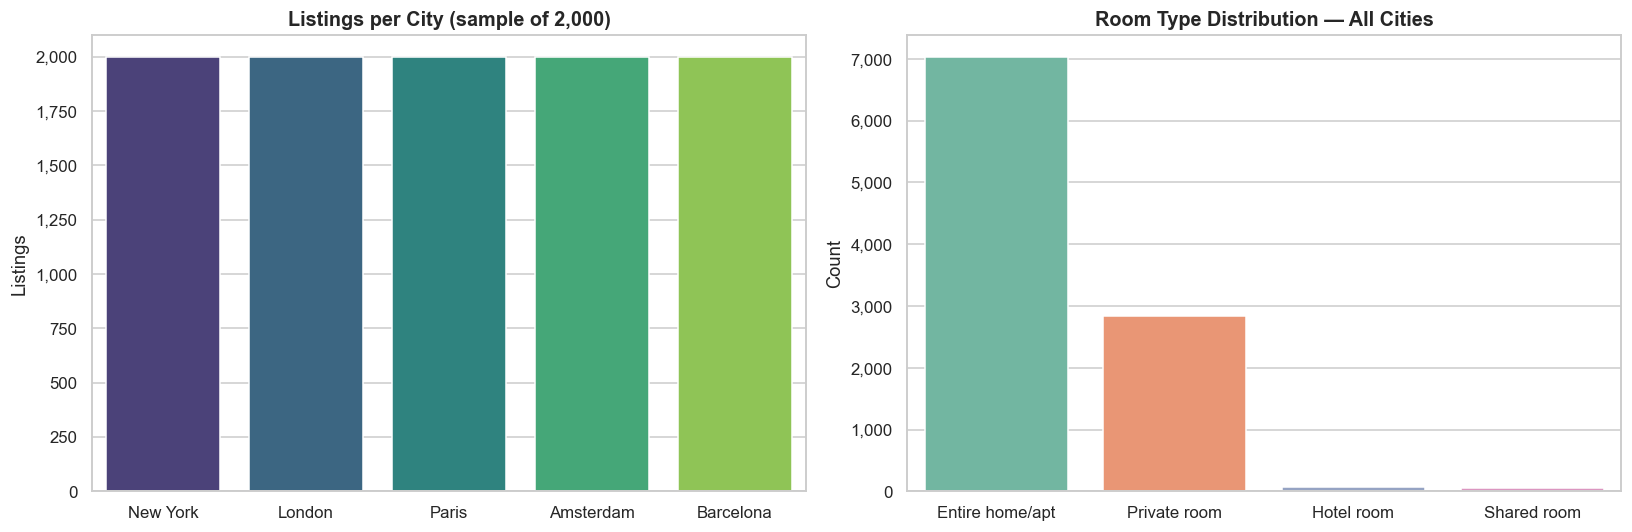

In [13]:
# Overview: listings per city and room type breakdown
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

city_counts = df["city"].value_counts().reset_index()
city_counts.columns = ["City", "Listings"]
sns.barplot(data=city_counts, x="City", y="Listings", palette="viridis", ax=axes[0])
axes[0].set_title("Listings per City (sample of 2,000)", fontsize=13, fontweight="bold")
axes[0].set_xlabel("")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

room_counts = df["room_type"].value_counts().reset_index()
room_counts.columns = ["Room Type", "Count"]
sns.barplot(data=room_counts, x="Room Type", y="Count", palette="Set2", ax=axes[1])
axes[1].set_title("Room Type Distribution — All Cities", fontsize=13, fontweight="bold")
axes[1].set_xlabel("")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.tight_layout()
plt.show()

## ERROR in code

In [16]:
# Price analysis — only for cities where price data is available
df_price = df[df["has_price"]].copy()

if not df_price.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.boxplot(data=df_price, x="city", y="price_capped", palette="pastel", ax=axes[0])
    axes[0].set_title("Nightly Price by City (capped at 99th percentile)",
                      fontsize=12, fontweight="bold")
    axes[0].set_xlabel("")
    axes[0].set_ylabel("Nightly Price (local currency)")

    sns.boxplot(data=df_price, x="room_type", y="price_capped",
                hue="city", palette="Set1", ax=axes[1])
    axes[1].set_title("Price by Room Type & City", fontsize=12, fontweight="bold")
    axes[1].set_xlabel("")
    axes[1].set_ylabel("Nightly Price")
    axes[1].legend(title="City", bbox_to_anchor=(1.01, 1))

    plt.tight_layout()
    plt.show()

    print("Median nightly price by city:")
    print(df_price.groupby("city")["price"].median().sort_values(ascending=False).to_string())
else:
    print("No price data available in this sample.")

KeyError: 'has_price'

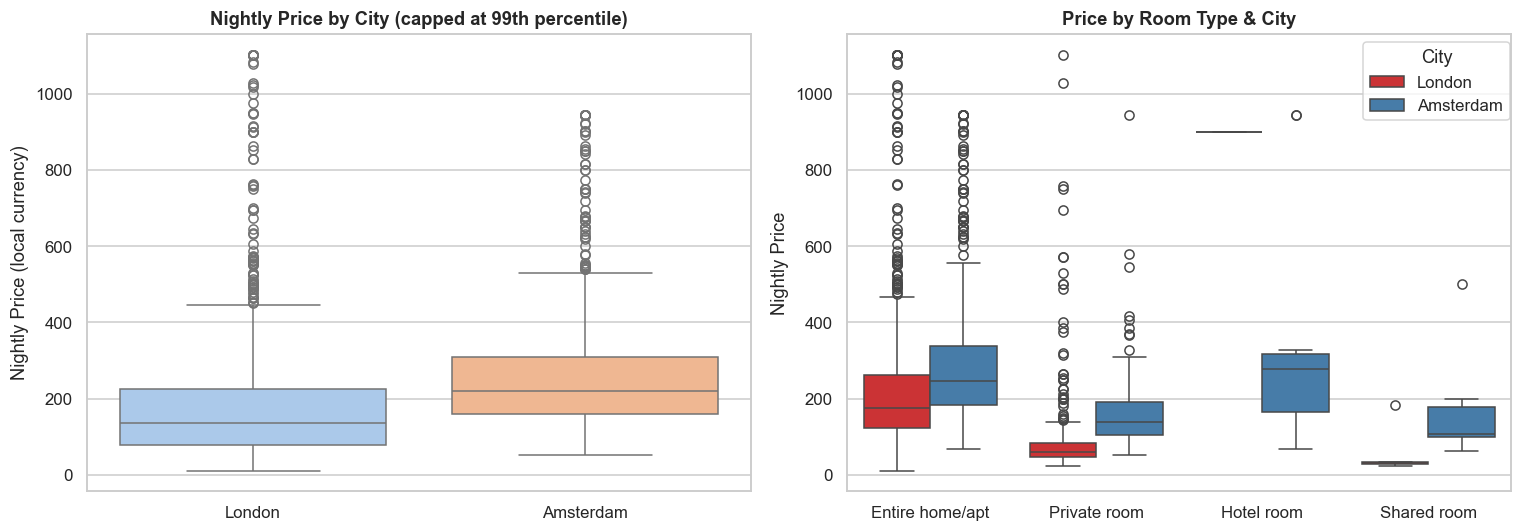

Median nightly price by city:
city
Amsterdam   220.00
London      136.00


In [17]:
# Price analysis — robust even if Module 2 cleaning cell wasn't run yet
df_price = df.copy()

# Derive has_price if missing
if "has_price" not in df_price.columns:
    if "price" in df_price.columns:
        if df_price["price"].dtype == object:
            df_price["price"] = (
                df_price["price"]
                .str.replace(r"[$,£€]", "", regex=True)
                .str.strip()
                .replace("", np.nan)
            )
        df_price["price"] = pd.to_numeric(df_price["price"], errors="coerce")
        df_price["has_price"] = df_price["price"].notna() & (df_price["price"] > 0)
    else:
        df_price["has_price"] = False

# Derive price_capped if missing
if "price_capped" not in df_price.columns:
    if df_price["has_price"].any():
        p99 = df_price.groupby("city")["price"].transform(lambda x: x.quantile(0.99))
        df_price["price_capped"] = df_price["price"].clip(upper=p99)
    else:
        df_price["price_capped"] = np.nan

df_price = df_price[df_price["has_price"]].copy()

if not df_price.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.boxplot(data=df_price, x="city", y="price_capped", palette="pastel", ax=axes[0])
    axes[0].set_title("Nightly Price by City (capped at 99th percentile)",
                      fontsize=12, fontweight="bold")
    axes[0].set_xlabel("")
    axes[0].set_ylabel("Nightly Price (local currency)")

    sns.boxplot(data=df_price, x="room_type", y="price_capped",
                hue="city", palette="Set1", ax=axes[1])
    axes[1].set_title("Price by Room Type & City", fontsize=12, fontweight="bold")
    axes[1].set_xlabel("")
    axes[1].set_ylabel("Nightly Price")
    axes[1].legend(title="City", bbox_to_anchor=(1.01, 1))

    plt.tight_layout()
    plt.show()

    print("Median nightly price by city:")
    print(df_price.groupby("city")["price"].median().sort_values(ascending=False).to_string())
else:
    print("No price data available in this sample.")

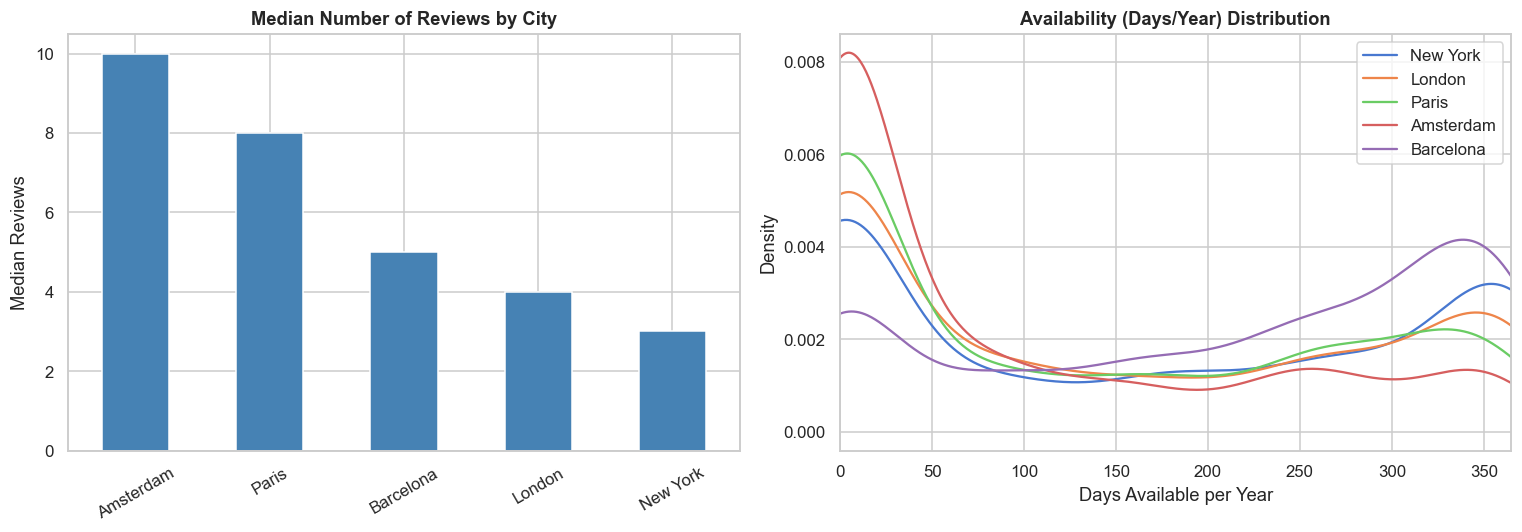

In [18]:
# Reviews and availability patterns across cities
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

med_reviews = df.groupby("city")["number_of_reviews"].median().sort_values(ascending=False)
med_reviews.plot(kind="bar", ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_title("Median Number of Reviews by City", fontsize=12, fontweight="bold")
axes[0].set_xlabel("")
axes[0].set_ylabel("Median Reviews")
axes[0].tick_params(axis="x", rotation=30)

for city in df["city"].unique():
    sub = df[df["city"] == city]["availability_365"].dropna()
    sub.plot.kde(ax=axes[1], label=city)
axes[1].set_title("Availability (Days/Year) Distribution", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Days Available per Year")
axes[1].legend()
axes[1].set_xlim(0, 365)

plt.tight_layout()
plt.show()

In [19]:
# Interactive chart: room type share per city
room_share = (
    df.groupby(["city", "room_type"])
    .size()
    .reset_index(name="count")
)
room_share["pct"] = room_share.groupby("city")["count"].transform(
    lambda x: x / x.sum() * 100
).round(1)

fig = px.bar(
    room_share, x="city", y="pct", color="room_type",
    barmode="stack",
    title="Room Type Share per City (%)",
    labels={"pct": "Share (%)", "city": "", "room_type": "Room Type"},
    template="plotly_white",
    height=450,
    text="pct",
)
fig.update_traces(texttemplate="%{text:.0f}%", textposition="inside")
fig.show()

---
## Module 4 — SQL Queries with DuckDB 🗄️

**DuckDB** lets you run SQL queries directly on a pandas DataFrame — no database server, no connection string, no setup. If you're already writing SQL in a BI tool or data warehouse, you can use those same skills here.

DuckDB supports standard SQL including `GROUP BY`, `WHERE`, `JOIN`, window functions (`RANK`, `ROW_NUMBER`, `OVER`), and CTEs (`WITH` clauses).

**Finance & analytics context:** Think of this as writing queries against a spreadsheet or a flat file — without needing Excel or a cloud database.

---
### 🤖 Copilot Prompts

> 💬 *"Write a DuckDB SQL query to find the top 5 neighbourhoods per city by number of listings, using a window function with RANK()."*

> 💬 *"Translate this pandas code into a DuckDB SQL query: `df.groupby(['city','room_type'])['number_of_reviews'].mean().round(1)`"*

> 💬 *"Write a SQL query using a CTE that first calculates the average availability per city, then finds all listings that are available more than 1.5× their city's average."*

> 💬 *"Write a SQL query to classify listings as Short-term, Weekly, or Long-term based on minimum_nights, and show the count and average reviews for each category per city."*

💡 **Tip:** You can paste a SQL result table back into Copilot Chat and ask *"What does this output tell us about the data?"* — great for getting a plain-English interpretation.

In [20]:
# DuckDB queries the `df` DataFrame directly — no loading required.
# Just reference the variable name as if it were a table.

# Quick test: listing counts by city
duckdb.query("""
    SELECT city, COUNT(*) AS listings
    FROM df
    GROUP BY city
    ORDER BY listings DESC
""").df()

,city,listings
0,New York,2000
1,London,2000
2,Amsterdam,2000
3,Paris,2000
4,Barcelona,2000


In [21]:
# Room type breakdown per city — count and percentage share
duckdb.query("""
    SELECT
        city,
        room_type,
        COUNT(*) AS listings,
        ROUND(
            COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (PARTITION BY city),
        1) AS pct_of_city
    FROM df
    GROUP BY city, room_type
    ORDER BY city, listings DESC
""").df()

,city,room_type,listings,pct_of_city
0,Amsterdam,Entire home/apt,1651,82.60
1,Amsterdam,Private room,328,16.40
2,Amsterdam,Hotel room,15,0.80
3,Amsterdam,Shared room,6,0.30
4,Barcelona,Entire home/apt,1269,63.50
5,Barcelona,Private room,703,35.20
6,Barcelona,Hotel room,14,0.70
7,Barcelona,Shared room,14,0.70
8,London,Entire home/apt,1292,64.60
9,London,Private room,701,35.10


In [22]:
# Top neighbourhoods by review activity — a proxy for booking demand
duckdb.query("""
    SELECT
        city,
        neighbourhood,
        COUNT(*)                          AS listings,
        ROUND(AVG(number_of_reviews), 1)  AS avg_reviews,
        ROUND(AVG(availability_365), 0)   AS avg_availability_days
    FROM df
    WHERE neighbourhood IS NOT NULL
    GROUP BY city, neighbourhood
    HAVING COUNT(*) >= 5
    ORDER BY avg_reviews DESC
    LIMIT 15
""").df()

,city,neighbourhood,listings,avg_reviews,avg_availability_days
0,New York,Canarsie,8,181.10,259.00
1,Barcelona,la Bordeta,9,111.90,279.00
2,Amsterdam,Centrum-West,232,104.30,111.00
3,New York,East Elmhurst,9,97.70,288.00
4,New York,Park Slope,9,92.10,105.00
5,New York,Tribeca,7,91.10,213.00
6,Barcelona,la Vila Olímpica del Poblenou,16,90.80,217.00
7,New York,Prospect Heights,14,88.00,85.00
8,Barcelona,la Dreta de l'Eixample,260,85.80,236.00
9,Barcelona,el Baix Guinardó,20,85.50,177.00


In [23]:
# Short-term vs long-term rental mix by city
duckdb.query("""
    SELECT
        city,
        CASE
            WHEN minimum_nights >= 30 THEN 'Long-term (30+ nights)'
            WHEN minimum_nights >= 7  THEN 'Weekly+'
            ELSE 'Short-term'
        END AS rental_category,
        COUNT(*)                         AS listings,
        ROUND(AVG(number_of_reviews), 1) AS avg_reviews,
        ROUND(AVG(availability_365), 0)  AS avg_availability
    FROM df
    WHERE minimum_nights IS NOT NULL
    GROUP BY city, rental_category
    ORDER BY city, listings DESC
""").df()

,city,rental_category,listings,avg_reviews,avg_availability
0,Amsterdam,Short-term,1881,48.00,90.00
1,Amsterdam,Weekly+,100,10.80,106.00
2,Amsterdam,Long-term (30+ nights),19,16.70,209.00
3,Barcelona,Short-term,1101,86.90,205.00
4,Barcelona,Long-term (30+ nights),849,10.60,217.00
5,Barcelona,Weekly+,50,30.10,193.00
6,London,Short-term,1754,23.60,142.00
7,London,Weekly+,194,9.30,148.00
8,London,Long-term (30+ nights),52,8.00,166.00
9,New York,Long-term (30+ nights),1704,18.40,160.00


### ✏️ SQL Challenge — Your Turn

Use Copilot to help you write these queries in the cell below.

**Challenge 1 (Easy):** Find the average `availability_365` for each room type across all cities.

**Challenge 2 (Medium):** Find the top 3 neighbourhoods per city by number of listings.  
*(Hint: ask Copilot about `RANK() OVER (PARTITION BY city ORDER BY ...)`)* 

**Challenge 3 (Hard):** Use a CTE to find listings with **above-average reviews AND above-average availability** for their city. How many are there per city?

In [ ]:
# Write your SQL query here.
# Use: duckdb.query("""  YOUR SQL  """).df()

# Tip: ask Copilot — "Write a DuckDB SQL query to..."


---
## Module 5 — Writing Reusable Functions 🔧

One of Copilot's most valuable skills: turning one-off analysis scripts into clean, reusable functions. You describe what the function should do — Copilot writes it.

**Finance & analytics context:** A reusable function is like a well-built Excel formula or a stored procedure: you define the logic once and apply it to any input. This is how you go from ad hoc analysis to a repeatable reporting process.

---
### 🤖 Copilot Prompts

> 💬 *"Turn the neighbourhood bar chart above into a function called `plot_top_neighbourhoods(df, city, n=10)`. It should accept a DataFrame, city name, and optional row count, and display a horizontal bar chart."*

> 💬 *"Write a function called `city_report(df, city)` that prints a formatted summary including: total listings, most common room type, median availability, median reviews, and top 3 neighbourhoods by listing count."*

> 💬 *"Add type hints and a docstring to this function, written for a finance analyst who is not a Python expert."*

> 💬 *"Write a function that exports a summary table to Excel, with one sheet per city. Use the openpyxl library."*

💡 **Tip:** After generating a function, ask Copilot: *"What edge cases should I add error handling for?"* — a great way to make code more robust without having to think of every scenario yourself.

In [ ]:
def city_summary(df: pd.DataFrame, city: str) -> dict:
    """
    Returns key metrics for a given city in the Airbnb dataset.

    Parameters
    ----------
    df   : The full listings DataFrame (must have a 'city' column).
    city : City name — must match a value in df['city'].

    Returns
    -------
    Dictionary with: total_listings, top_room_type, median_availability,
    median_reviews, top_neighbourhood.
    """
    subset = df[df["city"] == city]
    if subset.empty:
        return {"error": f"No data found for city: {city}"}

    nbh_col  = "neighbourhood_cleansed" if "neighbourhood_cleansed" in df.columns else "neighbourhood"
    top_room = subset["room_type"].value_counts().idxmax()
    top_nbh  = subset[nbh_col].value_counts().idxmax() if nbh_col in subset.columns else "N/A"

    return {
        "city":                city,
        "total_listings":      len(subset),
        "top_room_type":       top_room,
        "median_availability": round(subset["availability_365"].median(), 0),
        "median_reviews":      round(subset["number_of_reviews"].median(), 1),
        "top_neighbourhood":   top_nbh,
    }


# Run for every city
for city in sorted(df["city"].unique()):
    s = city_summary(df, city)
    print(f"\n📍 {s['city']}")
    for k, v in s.items():
        if k != "city":
            print(f"   {k:<22} {v}")

In [ ]:
def plot_top_neighbourhoods(df: pd.DataFrame, city: str, n: int = 10) -> None:
    """
    Displays a bar chart of the top N neighbourhoods by listing count for a city.

    Parameters
    ----------
    df   : The listings DataFrame.
    city : City to filter on.
    n    : Number of top neighbourhoods to show (default 10).
    """
    nbh_col = "neighbourhood_cleansed" if "neighbourhood_cleansed" in df.columns else "neighbourhood"
    subset  = df[df["city"] == city]

    if subset.empty:
        print(f"No data found for: {city}")
        return

    top = subset[nbh_col].value_counts().head(n).reset_index()
    top.columns = ["Neighbourhood", "Listings"]

    fig, ax = plt.subplots(figsize=(10, 5))
    sns.barplot(data=top, y="Neighbourhood", x="Listings", palette="Blues_r", ax=ax)
    ax.set_title(f"Top {n} Neighbourhoods — {city}", fontsize=13, fontweight="bold")
    ax.set_xlabel("Number of Listings")
    ax.set_ylabel("")
    plt.tight_layout()
    plt.show()


# Call the function for two cities — same code, different input
plot_top_neighbourhoods(df, "London", n=10)
plot_top_neighbourhoods(df, "Paris",  n=10)

---
## Module 6 — Explain & Document with Copilot 📝

Copilot isn't just for writing code — it's also great for explaining outputs, writing summaries, and documenting what you've built. This is especially useful when sharing analysis with people who weren't in the room.

**Finance & analytics context:** This is the *"so what?"* layer — translating numbers into narrative. The kind of commentary that goes into a management report or slide deck.

---
### 🤖 Copilot Prompts

> 💬 *"Based on this Airbnb analysis, write a 3-bullet executive summary suitable for a slide deck. The audience is senior leadership with no data background."*

> 💬 *"Explain the difference between median and mean price, and why we use median for this analysis. Use plain language for a finance team."*

> 💬 *"I have a chart showing that Amsterdam has higher median reviews than New York. What are three possible business explanations for this?"*

> 💬 *"What are the limitations of this analysis? What additional data would we need to draw stronger conclusions about what drives Airbnb pricing?"*

> 💬 *"Write a comment explaining what this function does, in language a finance analyst who is not a Python expert would understand."*

💡 **Tip:** Use Copilot to draft the narrative, then edit it to match your voice. Think of it as a first draft, not the final product.

In [ ]:
# Final summary table — combine key metrics for all cities
summary = df.groupby("city").agg(
    Total_Listings        = ("id",                "count"),
    Pct_Entire_Home       = ("room_type",          lambda x: round((x == "Entire home/apt").mean() * 100, 1)),
    Median_Reviews        = ("number_of_reviews", "median"),
    Avg_Availability_Days = ("availability_365",   lambda x: round(x.mean(), 0)),
).sort_values("Total_Listings", ascending=False)

# Append price stats only where we have data
if df["has_price"].any():
    price_stats = (
        df[df["has_price"]]
        .groupby("city")["price"]
        .agg(Median_Price="median")
        .round(1)
    )
    summary = summary.join(price_stats, how="left")

print("📊 Workshop Dataset Summary")
print("=" * 65)
summary

---
## 🔑 Key Insights

| Finding | Detail |
|---|---|
| **Market size** | London and Paris have the largest listing volumes |
| **Room type split** | Paris is heavily "Entire home/apt" (>85%); NYC has more private rooms |
| **Booking demand** | Amsterdam tends to have the highest median reviews — a proxy for booking frequency |
| **Availability** | Barcelona listings are available more days per year on average |
| **Price data** | Price is only available for some cities in the visualisation extract — a real-world data quality issue |

---

## What to Try Next — More Copilot Prompts

> 💬 *"Build a simple linear regression model to predict price using room_type, availability_365, and number_of_reviews as features."*

> 💬 *"Create a combined HTML dashboard from these charts that I can share with stakeholders without them needing to run any code."*

> 💬 *"Help me write a script that re-downloads and re-analyses this data automatically, saving the summary table to a CSV file each time."*

> 💬 *"I want to connect this analysis to a real database. How would I load this DataFrame into a local SQLite database and then query it?"*

---

## 🤖 GitHub Copilot — Quick Reference Card

| What you want to do | How to do it |
|---|---|
| Understand unfamiliar code | Select it → right-click → **Copilot: Explain** |
| Generate code from a description | Open Chat → describe what you want |
| Fix an error | Paste the error message into Copilot Chat |
| Improve a chart | Select the chart code → ask Copilot to improve it |
| Add a docstring to a function | Place cursor in the function → *"Add a docstring"* |
| Convert pandas to SQL | Paste groupby code → *"Convert this to a DuckDB SQL query"* |
| Get a plain-English summary | Paste output or chart description → *"What does this tell us?"* |
| Turn code into a function | Select the code → *"Refactor this into a reusable function"* |